# Lavaca Bay SFINCS Tutorial

This notebook demonstrates how to build and run a
[SFINCS](https://sfincs.readthedocs.io) coastal flood model for
Lavaca Bay, Texas using the `coastal_calibration` Python API.

The workflow has three phases:

1. **Create** — build a SFINCS model from an Area of Interest (AOI)
   polygon using HydroMT-SFINCS.
2. **Run** — execute the full simulation pipeline: download forcing
   data, write SFINCS input files, run the model, produce a
   downscaled flood depth map, and compare results against NOAA
   tide-gauge observations.
3. **Visualize** — plot the flood depth map and station comparisons.

## Setup

In [1]:
from __future__ import annotations

import os
from pathlib import Path

notebook_dir = Path.cwd()  # assumes notebook is run from docs/examples/notebooks/
os.chdir(notebook_dir.parent / "lavaca-tx")

## 1. Create the SFINCS model

### Build the create configuration

`SfincsCreateConfig.from_dict` accepts a plain dictionary with the same
structure as the YAML file.

In [2]:
from coastal_calibration import SfincsCreateConfig, SfincsCreator, configure_logger

configure_logger(level="INFO")

create_config = SfincsCreateConfig.from_dict(
    {
        "aoi": "./aoi.geojson",
        "output_dir": "./output",
        "download_dir": "../downloads/lavaca_grid",
        "grid": {
            "resolution": 512,
            "crs": "utm",
            "rotated": False,
            "refinement": [
                {"polygon": "./refine.geojson", "level": 3},
            ],
        },
        "elevation": {
            "datasets": [
                {"name": "noaa_3m", "zmin": -20000, "source": "noaa_3m"},
                {"name": "gebco_15arcs", "zmin": -20000, "source": "gebco_15arcs"},
            ],
            "buffer_cells": 1,
        },
        "mask": {"zmin": -50.0, "boundary_zmax": -1.0, "reset_bounds": True},
        "subgrid": {
            "nr_subgrid_pixels": 4,
            "lulc_dataset": "esa_worldcover",
            "manning_land": 0.04,
            "manning_sea": 0.02,
        },
        "river_discharge": {
            "flowlines": "./discharge_nwm.geojson",
            "nwm_id_column": "flowpath_id",
        },
        "add_noaa_gages": True,
    }
)

### Run the create workflow

In [3]:
creator = SfincsCreator(create_config)
result = creator.run()
if not result.success:
    raise RuntimeError(f"Model creation failed at stage '{result.stages_failed}': {result.errors}")
print(result)

Coastal Calibration Workflow                                                    


Start Time: 2026-05-21 19:26:26                                                 


----------------------------------------                                        


Stage: create_grid                                                              


Start Time: 2026-05-21 19:26:26                                                 


...

  [✓] create_discharge: 0s                                                      


  [✓] create_subgrid: 28s                                                       


  [✓] create_obs: 0s                                                            


  [✓] create_write: 0s                                                          


WorkflowResult: SUCCESS
  Start:     2026-05-21 19:26:26
  End:       2026-05-21 19:26:57
  Duration:  30s
  Completed: create_grid, create_fetch_data, create_elevation, create_mask, create_boundary, create_discharge, create_subgrid, create_obs, create_write


### Inspect the created model

In [4]:
output = Path("output")
assert output.exists(), (
    f"Output directory not found: {output.resolve()} — run the create step first."
)

for f in sorted(output.iterdir()):
    if f.name.startswith(".") or f.suffix == ".log":
        continue
    size = f.stat().st_size
    label = f"{size / 1e6:.1f} MB" if size > 1e6 else f"{size / 1e3:.1f} KB"
    print(f"  {f.name:<30s} {label}")

  create_progress.json           2.2 KB
  create_result.json             1.3 KB
  gis                            0.1 KB
  obs_station_map.json           0.5 KB
  sfincs.inp                     0.9 KB
  sfincs.nc                      15.2 MB
  sfincs.obs                     0.2 KB
  sfincs_nwm.src                 0.1 KB
  sfincs_subgrid.nc              23.0 MB
  subgrid                        0.2 KB


## 2. Run the simulation pipeline

### Build the run configuration

`CoastalCalibConfig.from_dict` accepts the same dictionary structure as
the run YAML file.

In [5]:
from coastal_calibration import CoastalCalibConfig, CoastalCalibRunner

run_config = CoastalCalibConfig.from_dict(
    {
        "model": "sfincs",
        "simulation": {
            "start_date": "2025-06-01",
            "duration_hours": 100,
            "coastal_domain": "atlgulf",
            "meteo_source": "nwm_ana",
        },
        "boundary": {"source": "stofs"},
        "paths": {
            "work_dir": "./run",
            "raw_download_dir": "../downloads",
        },
        "download": {"enabled": True},
        "model_config": {
            "prebuilt_dir": "./output",
            "discharge_locations_file": "./output/sfincs_nwm.src",
            "merge_discharge": True,
            "forcing_to_mesh_offset_m": 0.0,  # STOFS already in NAVD88
            "vdatum_mesh_to_msl_m": 0.17,  # NAVD88 mesh -> MSL
            "include_precip": True,
            "include_wind": True,
            "include_pressure": True,
            "run_param_overrides": {
                "tspinup": 10800,
                "advection": 0,
                "viscosity": 0,
                "nuvisc": 0.01,
                "cdnrb": 3,
                "cdwnd": [0.0, 28.0, 50.0],
                "cdval": [0.001, 0.0025, 0.0025],
            },
            # Flood depth map — path to a high-resolution DEM.
            # Here we reuse the NOAA 3m DEM fetched during model creation.
            "floodmap_dem": "../downloads/lavaca_grid/noaa_3m.tif",
        },
    }
)

### Note on the SFINCS executable

The `sfincs_exe` field overrides the default PATH lookup for the SFINCS binary.
When running inside a pixi environment with the `sfincs` feature, the binary
is compiled automatically and available on PATH — no `sfincs_exe` needed.

If you compiled SFINCS manually, set `sfincs_exe` to the path of the binary.
If neither is available, the pipeline will complete all stages up to
`sfincs_run` and then fail at model execution.

### Run the pipeline

In [6]:
runner = CoastalCalibRunner(run_config)
result = runner.run()
if not result.success:
    raise RuntimeError(f"Model run failed at stage '{result.stages_failed}': {result.errors}")
print(result)

Coastal Calibration Workflow                                                    


Start Time: 2026-05-21 19:26:57                                                 


----------------------------------------                                        


Cleaned generated files from                                                    
docs/examples/lavaca-tx/run               


Stage: download                                                                 


...

  [✓] sfincs_write: 0s                                                          


  [✓] sfincs_run: 2m 51s                                                        


  [✓] sfincs_floodmap: 3m 40s                                                   


  [✓] sfincs_plot: 2s                                                           


WorkflowResult: SUCCESS
  Start:     2026-05-21 19:26:57
  End:       2026-05-21 19:34:05
  Duration:  7m 8s
  Completed: download, sfincs_symlinks, sfincs_data_catalog, sfincs_init, sfincs_timing, sfincs_forcing, sfincs_discharge, sfincs_precip, sfincs_wind, sfincs_pressure, sfincs_write, sfincs_run, sfincs_floodmap, sfincs_plot


## 3. View results

The pipeline generates station comparison plots (modeled vs. observed
water levels at NOAA CO-OPS tide gauges).

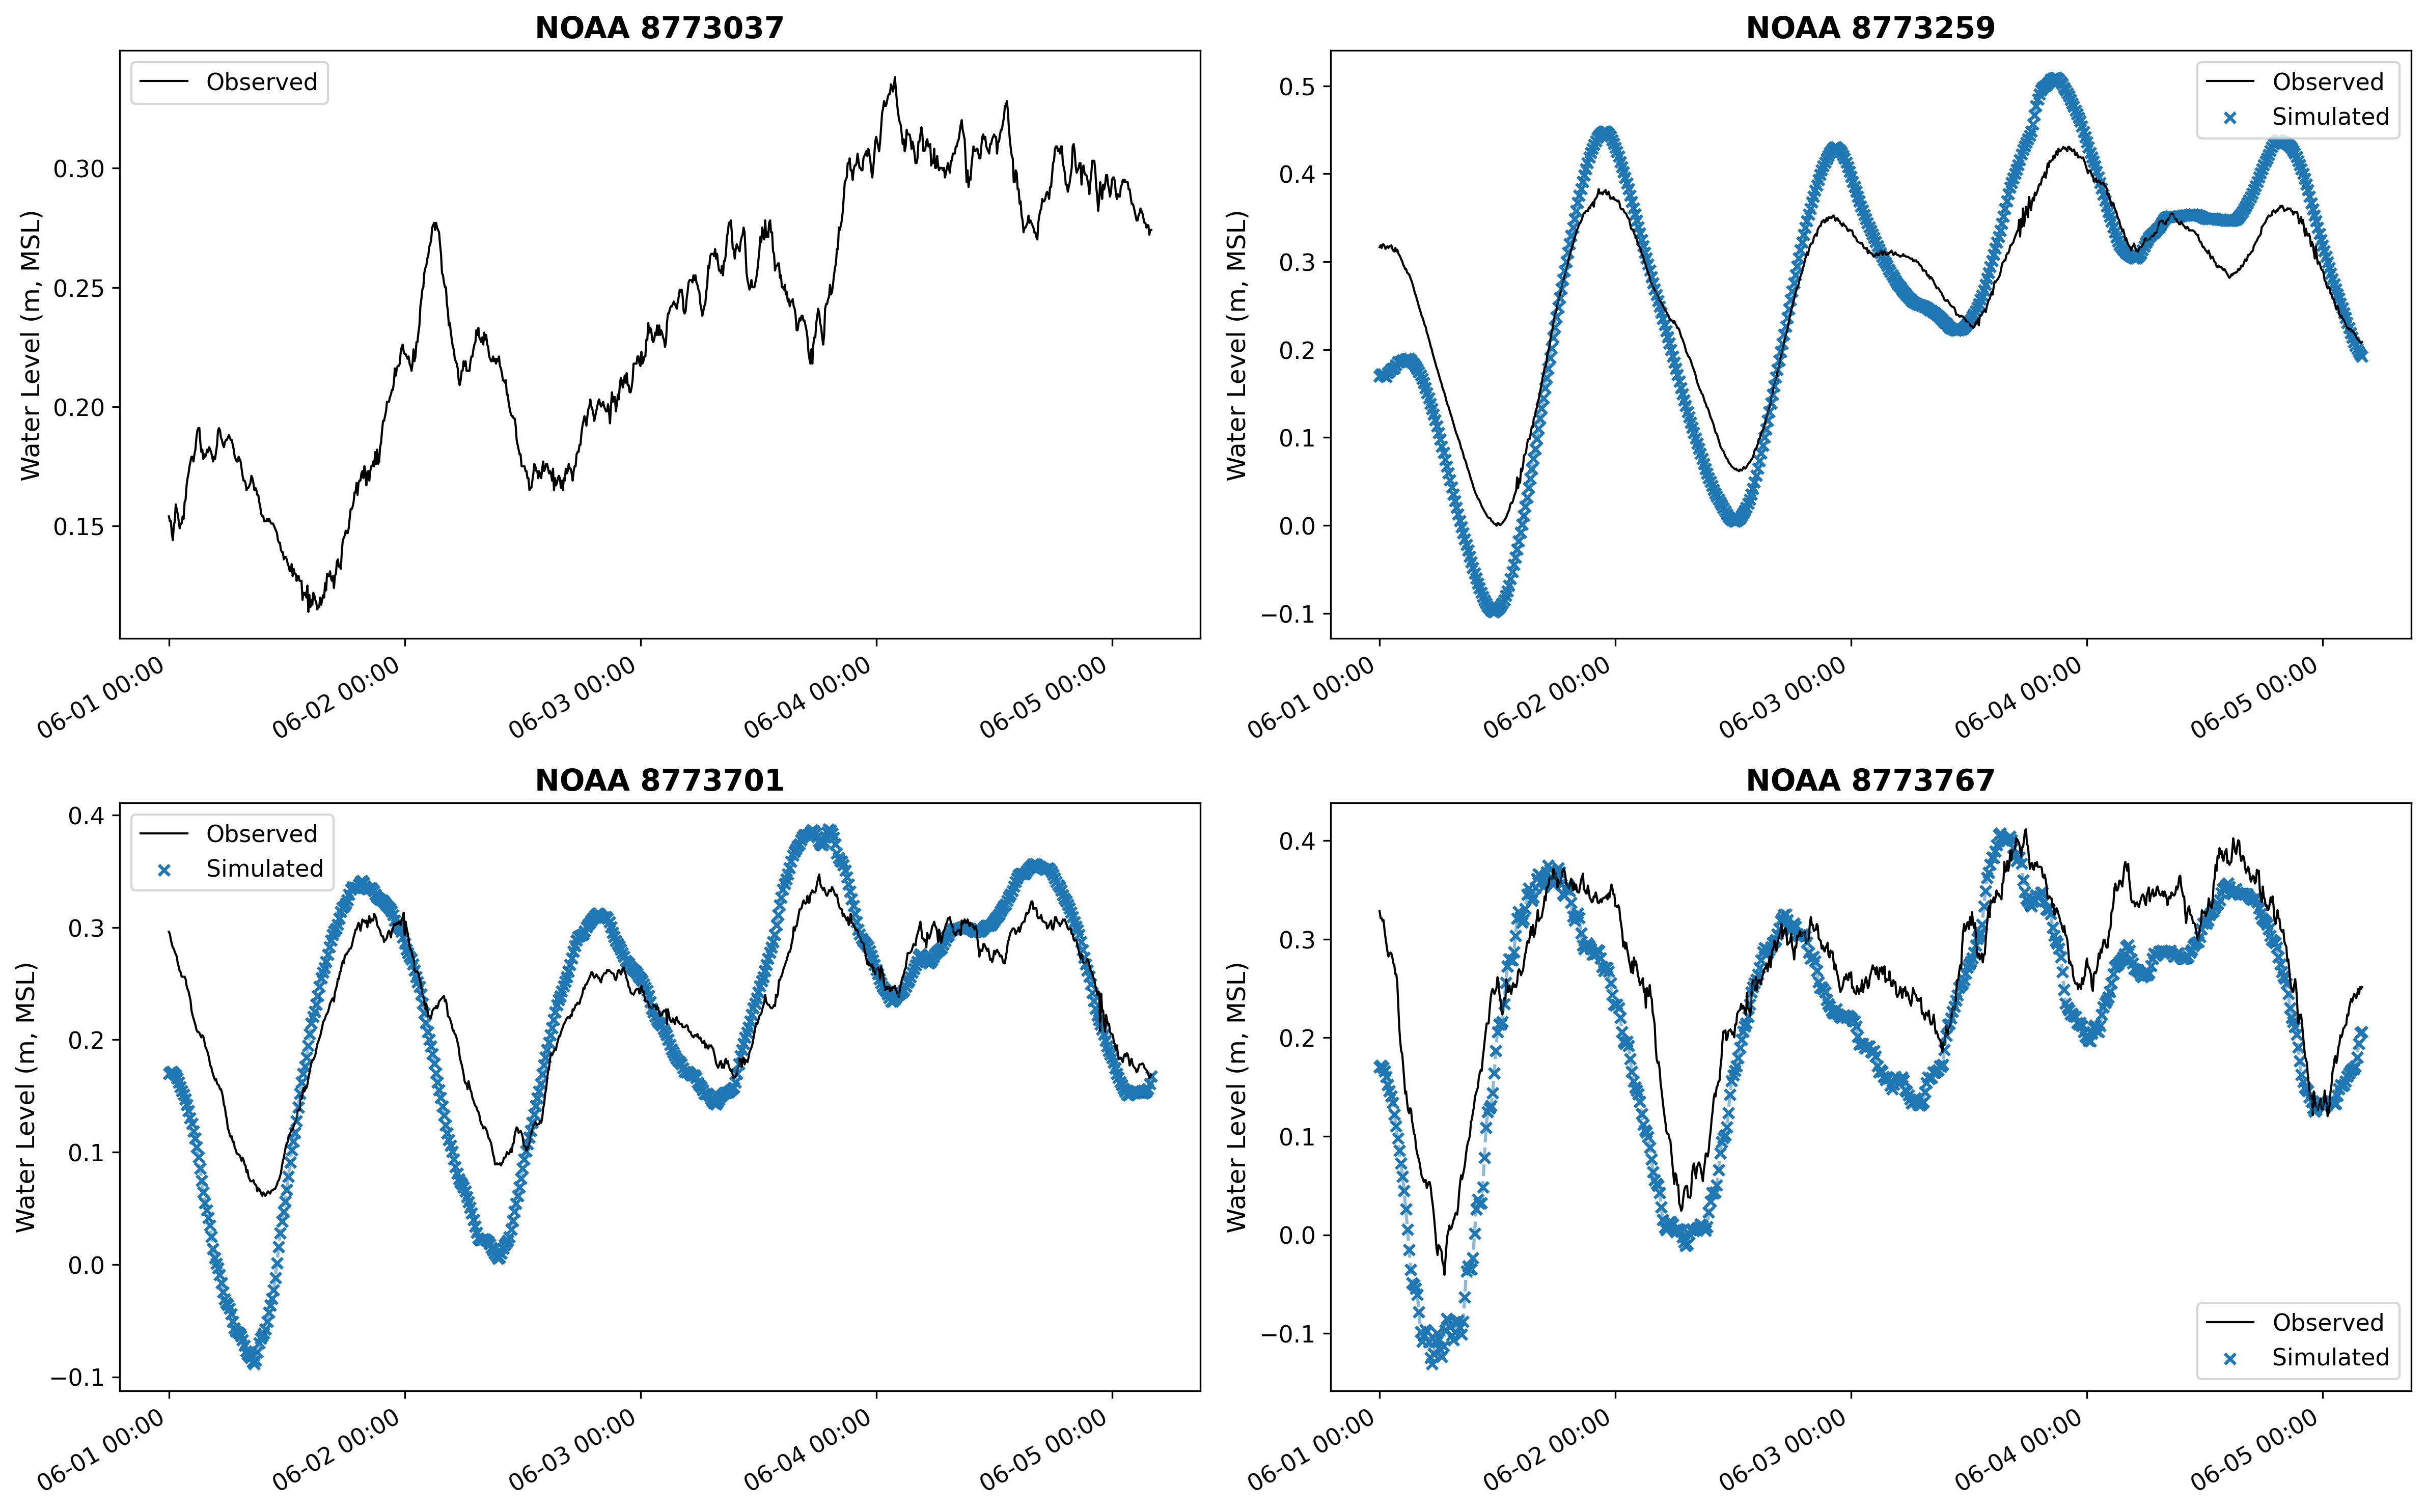

In [7]:
from IPython.display import Image, display

figs_dir = Path("run/sfincs_model/figs")
assert figs_dir.exists(), f"Results not found: {figs_dir.resolve()} — run the pipeline first."

for png in sorted(figs_dir.glob("stations_comparison_*.png")):
    display(Image(filename=str(png), width=800))

## 4. SFINCS mesh

The SFINCS model uses a quadtree grid with local refinement.  Coarser
cells (512 m) cover the offshore domain while regions near the coastline
and inside the bay are refined to smaller cell sizes (down to 64 m).

In [8]:
from coastal_calibration.plotting import SfincsGridInfo, plot_floodmap, plot_mesh

info = SfincsGridInfo.from_model_root("run/sfincs_model")
print(info)

SfincsGridInfo(quadtree, EPSG:32614)
  Faces:         70,723
  Edges:        142,599
  Level 1:       23,471 cells (512 m)
  Level 2:          545 cells (256 m)
  Level 3:        1,087 cells (128 m)
  Level 4:       45,620 cells (64 m)


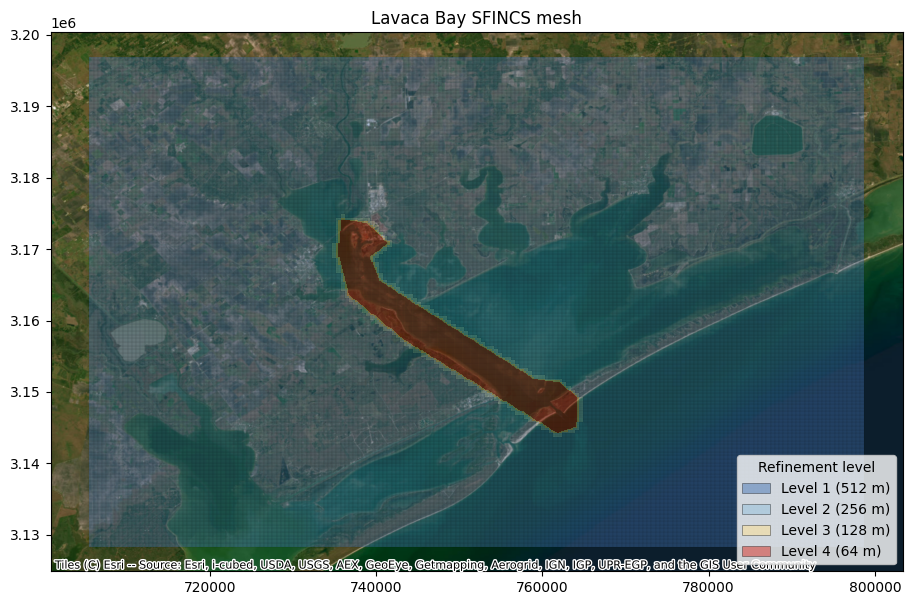

In [9]:
fig, ax = plot_mesh(info, title="Lavaca Bay SFINCS mesh")

## 5. Flood depth map

The pipeline automatically produces a downscaled flood depth map when
`floodmap_dem` is configured.  The `sfincs_floodmap` stage reads the
maximum water surface elevation (`zsmax`) from the SFINCS map output,
builds an index COG mapping DEM pixels to SFINCS grid cells, and
writes a Cloud Optimized GeoTIFF of flood depth at the DEM resolution.

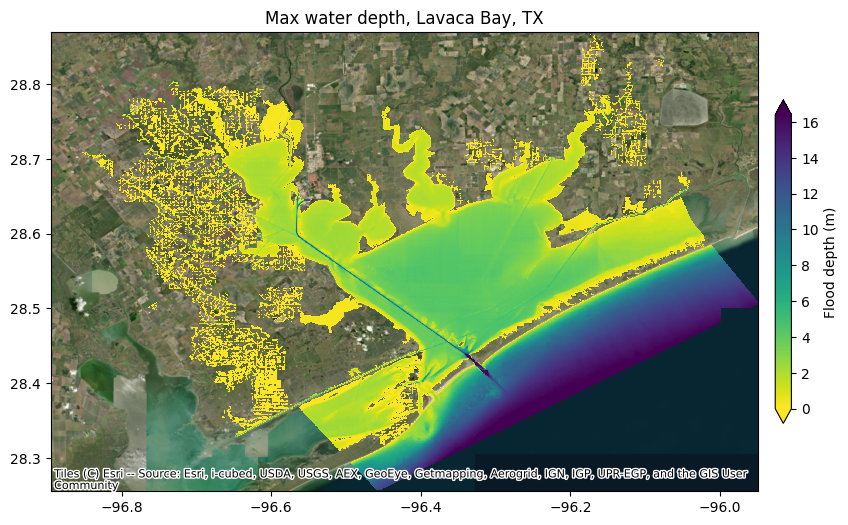

In [10]:
fig, ax = plot_floodmap(
    "run/sfincs_model/floodmap_hmax.tif",
    title="Max water depth, Lavaca Bay, TX",
)
fig.savefig("../images/lavaca_thumb.png", dpi=150, bbox_inches="tight")

The flood depth COG can be opened in QGIS or any GIS viewer.
You can also generate a flood depth map outside the pipeline
using the standalone function:

```python
from coastal_calibration.utils.floodmap import create_flood_depth_map

create_flood_depth_map(
    model_root="run/sfincs_model",
    dem_path="../downloads/lavaca_grid/noaa_3m.tif",
)
```

## 6. Load the time-dependent water-level field

The pipeline already produced station-comparison plots and a flood
depth map. The remainder of this notebook drives the post-processing
plotting API directly so you can produce custom views from the same
`sfincs_map.nc` output.

`load_sfincs_water_level` returns one canonical dataset with:

- `zs(time, face)` — water-surface elevation (m, MSL).
- `h(time, face)` — water depth, derived as `zs − zb`.
- `zb(face)` — static bed elevation.
- Mesh geometry (`node_x`, `node_y`, `face_nodes`) + `mesh_type` attr so
  the renderer knows how to dispatch.
- The detected CRS as a dataset attribute, so basemap reprojection
  Just Works.

In [11]:
from coastal_calibration.sfincs.outputs import load_sfincs_water_level

run_dir = Path("run/sfincs_model")
ds = load_sfincs_water_level(run_dir)
print(f"mesh_type     : {ds.attrs['mesh_type']}")
print(f"crs           : {ds.attrs.get('crs', '(not detected)')}")
print(f"dims          : {dict(ds.sizes)}")
print(f"time[0]       : {ds.time.values[0]}")
print(f"time[-1]      : {ds.time.values[-1]}")
print(f"zs range (m)  : {float(ds['zs'].min()):+.3f} .. {float(ds['zs'].max()):+.3f}")
print(f"h  range (m)  : {float(ds['h'].min()):+.3f} .. {float(ds['h'].max()):+.3f}")

mesh_type     : ugrid-quadtree
crs           : EPSG:32614
dims          : {'time': 101, 'face': 70723, 'node': 282892, 'face_node': 4}
time[0]       : 2025-06-01T00:00:00.000000000
time[-1]      : 2025-06-05T04:00:00.000000000
zs range (m)  : -0.339 .. +20.030
h  range (m)  : +0.000 .. +40.490


## 7. Pick a color range from wet cells only

`mask_dry=True` (the renderer default) hides cells with
`h ≤ dry_threshold`; the quantile we use for the color scale should
also be computed on the wet subset so dry-cell bed elevations don't
stretch the scale.

In [12]:
DRY_THRESHOLD = 0.05  # m — same default as plot_water_level
wet = ds["h"] > DRY_THRESHOLD
zs_wet = ds["zs"].where(wet)
q_lo, q_hi = 0.02, 0.98
vmin, vmax = (float(v) for v in zs_wet.quantile([q_lo, q_hi]).values)
print(f"color range (zs over wet cells): [{vmin:+.3f}, {vmax:+.3f}] m")

color range (zs over wet cells): [-0.247, +0.256] m


## 8. Three water-surface snapshots

Wet-cell masking is on by default, so dry land becomes transparent.
All three frames share the same `vmin`/`vmax` for cross-frame
comparison.

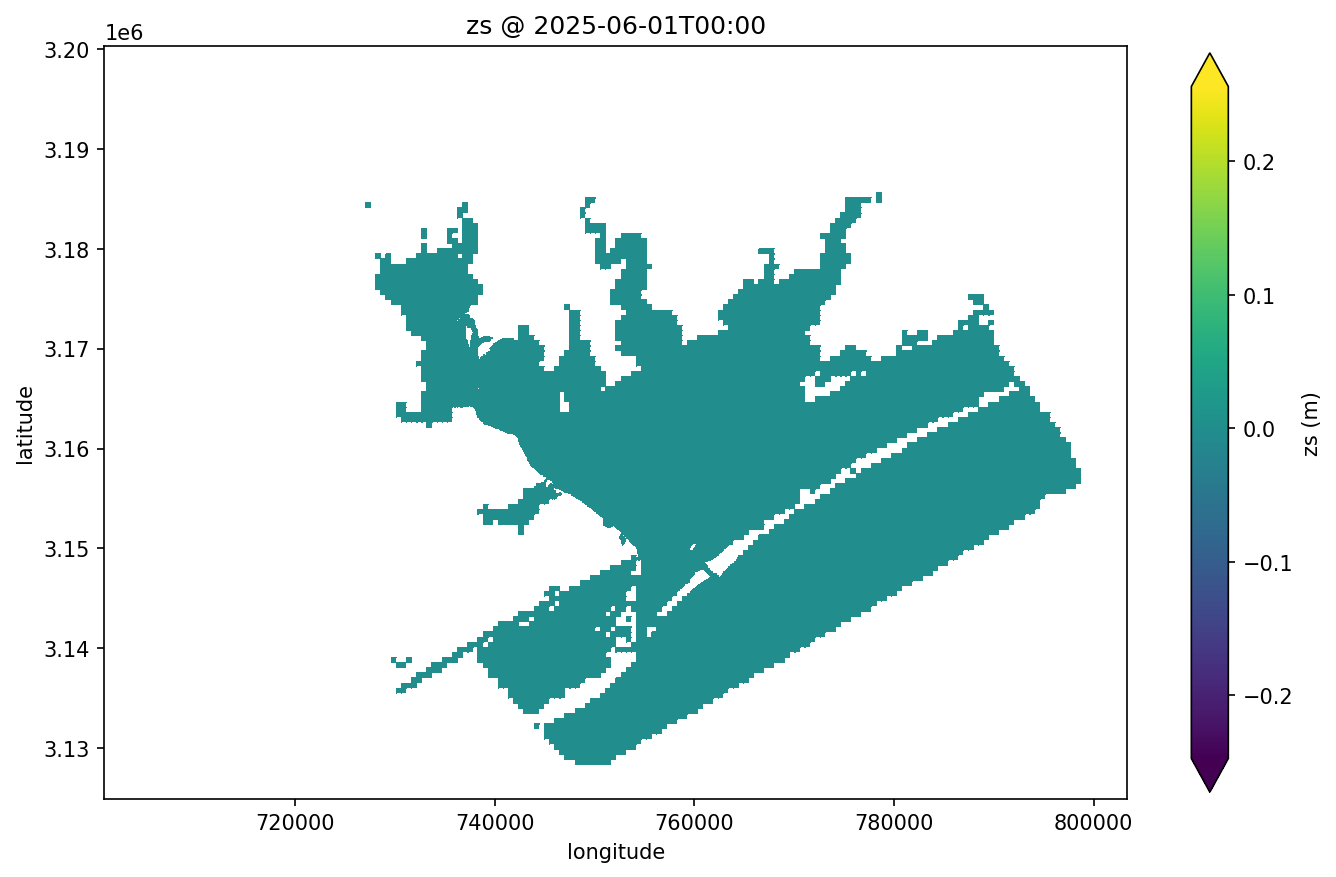

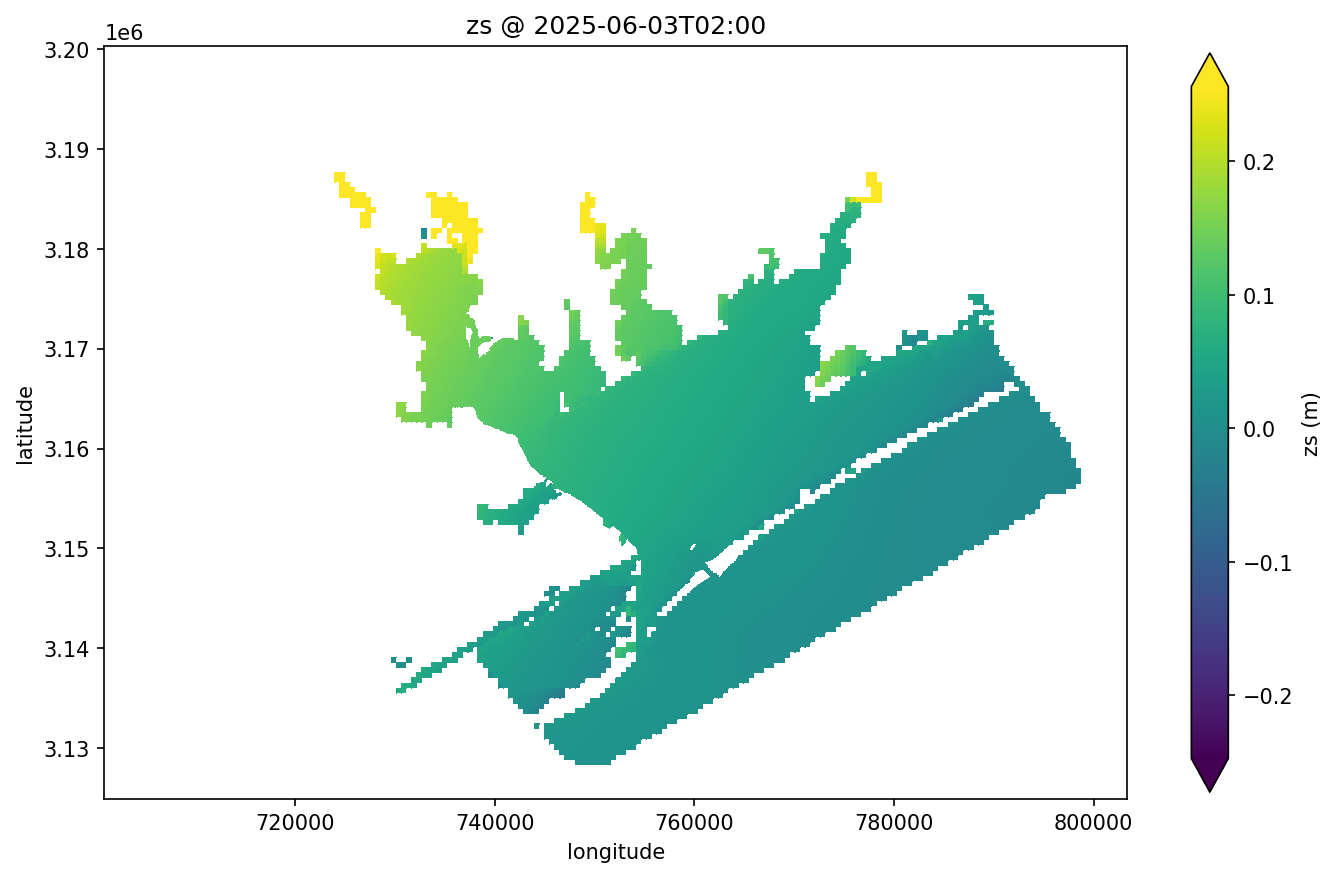

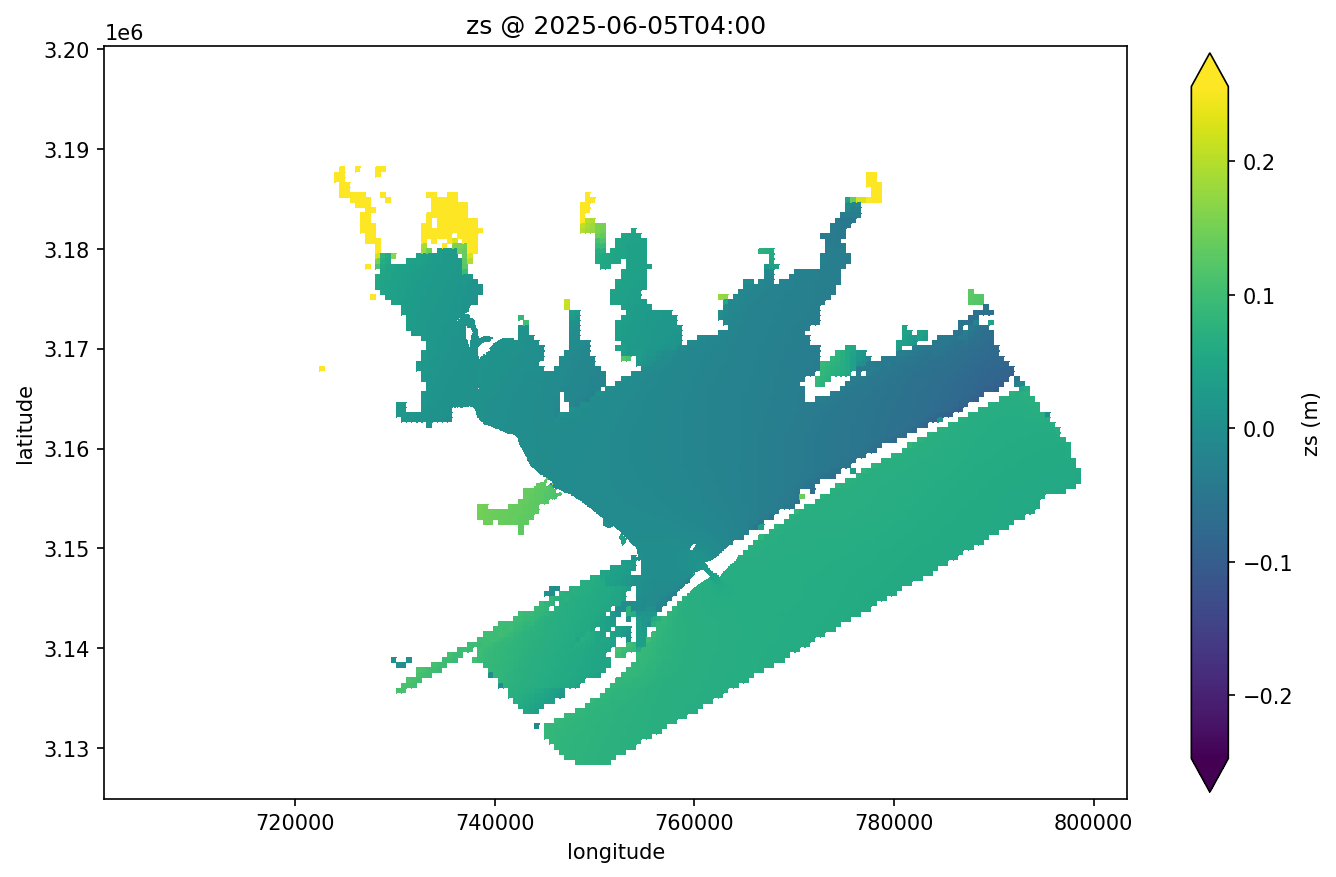

In [13]:
import matplotlib.pyplot as plt

from coastal_calibration.plotting import animate_water_level, plot_water_level

n_time = ds.sizes["time"]
snapshot_indices = [0, n_time // 2, n_time - 1]
snapshot_labels = ["first", "middle", "last"]
snapshots: list[Path] = []

for label, idx in zip(snapshot_labels, snapshot_indices, strict=True):
    fig, ax = plt.subplots(figsize=(11, 8))
    plot_water_level(
        ds,
        time=idx,
        variable="zs",
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        colorbar=True,
        mask_dry=True,
        dry_threshold=DRY_THRESHOLD,
    )
    out_png = figs_dir / f"water_level_snapshot_{label}.png"
    fig.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.close(fig)
    snapshots.append(out_png)

for png in snapshots:
    display(Image(filename=str(png), width=800))

## 9. Water depth (`h`)

Same renderer, just `variable="h"`. The wet-cell mask hides cells with
`h ≤ dry_threshold` (essentially zero depth), so the plot shows the
actual inundation depth across the wet domain.

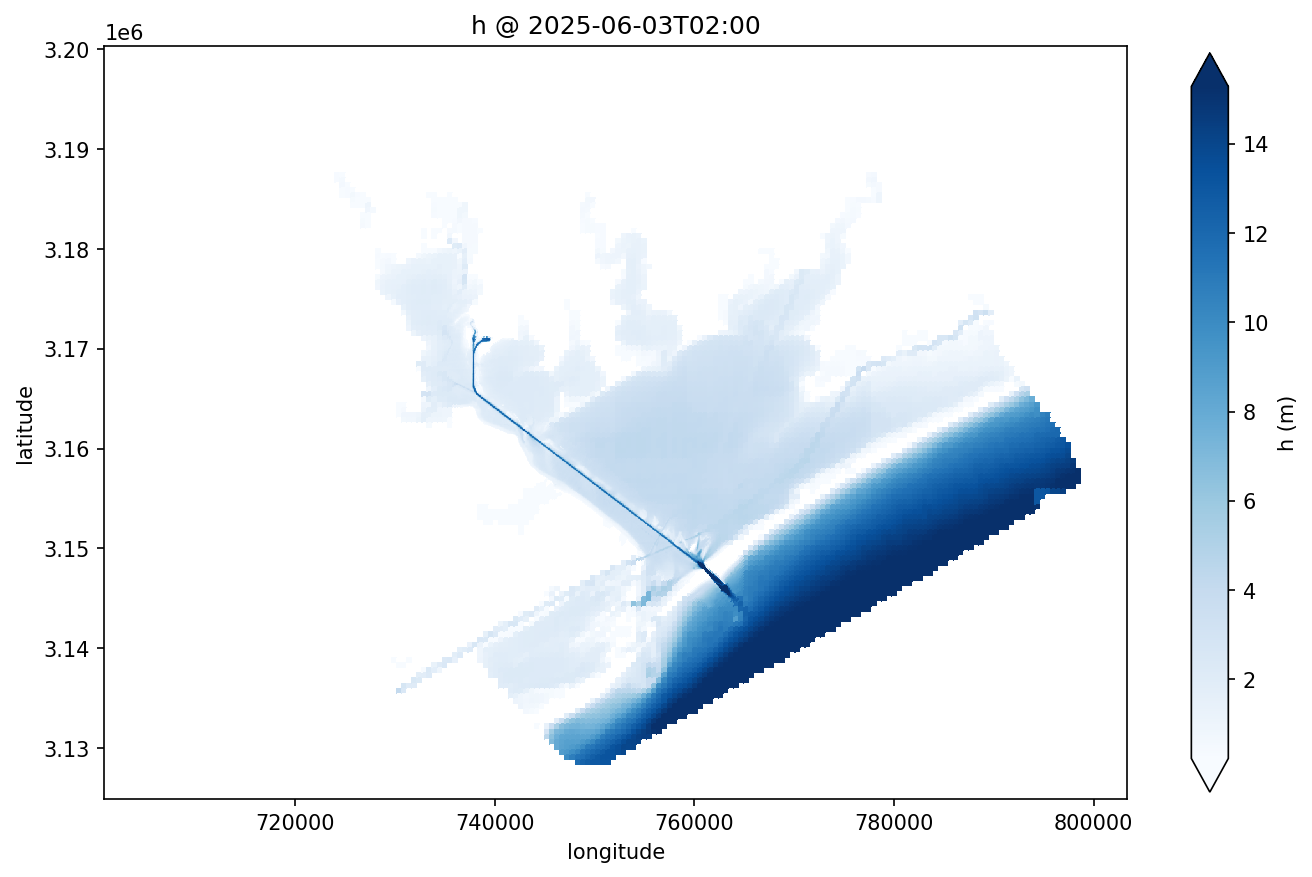

In [14]:
h_vmin, h_vmax = (float(v) for v in ds["h"].where(wet).quantile([q_lo, q_hi]).values)

fig, ax = plt.subplots(figsize=(11, 8))
plot_water_level(
    ds,
    time=snapshot_indices[1],
    variable="h",
    ax=ax,
    cmap="Blues",
    vmin=h_vmin,
    vmax=h_vmax,
    colorbar=True,
)
depth_png = figs_dir / "water_depth_snapshot.png"
fig.savefig(depth_png, dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(depth_png), width=800))

## 10. Water-level anomaly from the time-mean

A diverging colormap is most useful when zero is a *meaningful*
reference and values can sit on either side. For a single model run,
the natural diverging story is the **anomaly from the per-cell
time-mean**:

`zs_anom(t, x) = zs(t, x) − mean(zs over time at x)`

Subtracting each cell's static reference removes the bed-elevation
contamination at inundated upland cells (their local mean is
essentially their bed elevation, so the anomaly there is ≈ 0). What's
left is the *dynamic* signal — tidal phase, storm surge, set-up — order
±1 m even though the raw `zs` field spans tens of meters.

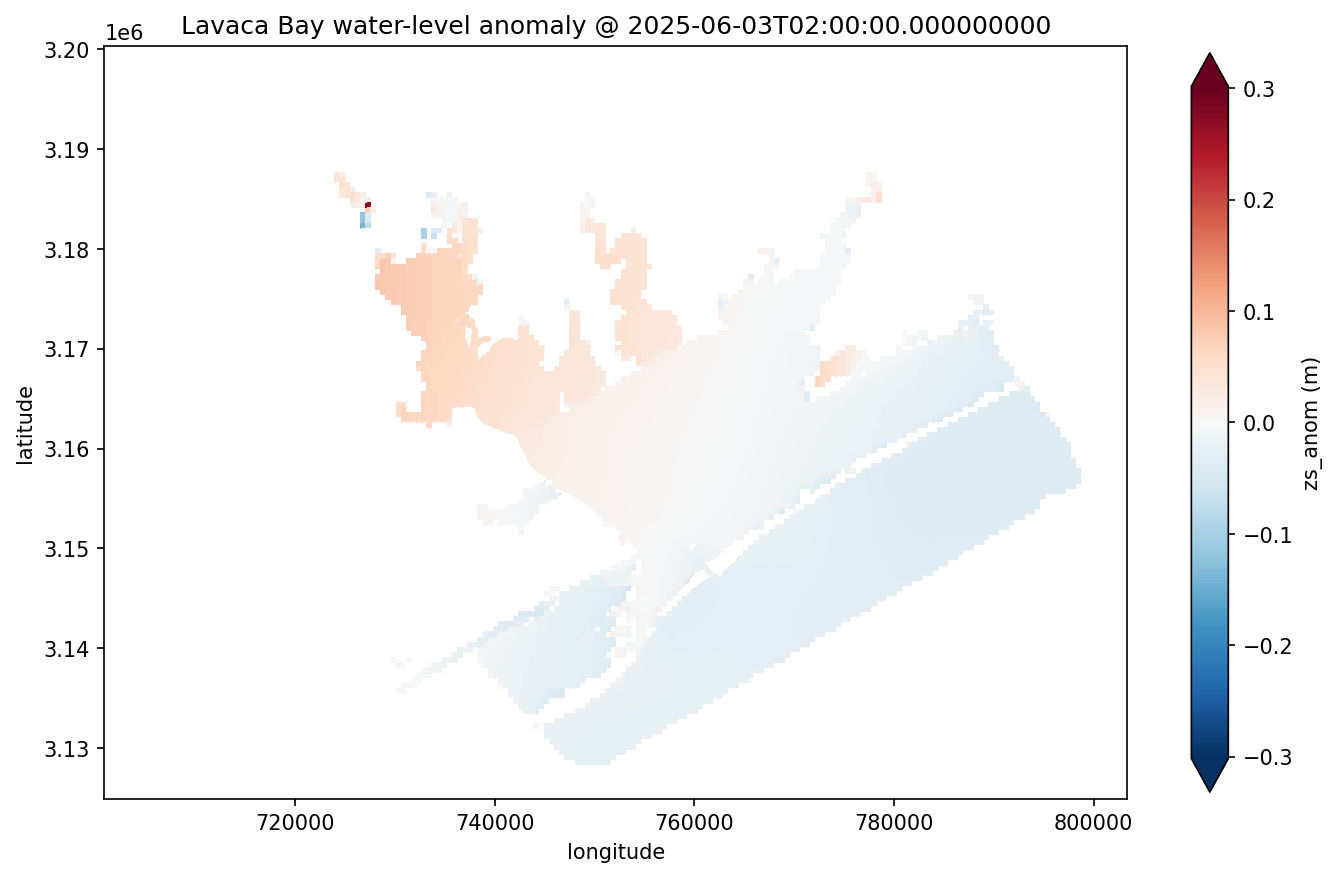

In [15]:
zs_anom = ds["zs"] - ds["zs"].mean("time")
ds_anom = ds.assign(zs_anom=zs_anom)
ds_anom["zs_anom"].attrs.update({"long_name": "water-level anomaly from time-mean", "units": "m"})

amp = float(abs(zs_anom.where(wet)).quantile(0.98).values)

fig, ax = plt.subplots(figsize=(11, 8))
plot_water_level(
    ds_anom,
    time=snapshot_indices[1],
    variable="zs_anom",
    ax=ax,
    cmap="RdBu_r",
    vmin=-amp,
    vmax=+amp,
    colorbar=True,
    title=f"Lavaca Bay water-level anomaly @ {ds.time.values[snapshot_indices[1]]}",
)
anomaly_png = figs_dir / "water_level_anomaly.png"
fig.savefig(anomaly_png, dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(anomaly_png), width=800))

## 11. Snapshot with a satellite basemap

`basemap=True` overlays Esri WorldImagery, reprojected from web
Mercator into the data CRS so the model coordinates remain unchanged.
Dry cells are transparent so the satellite imagery shows through.

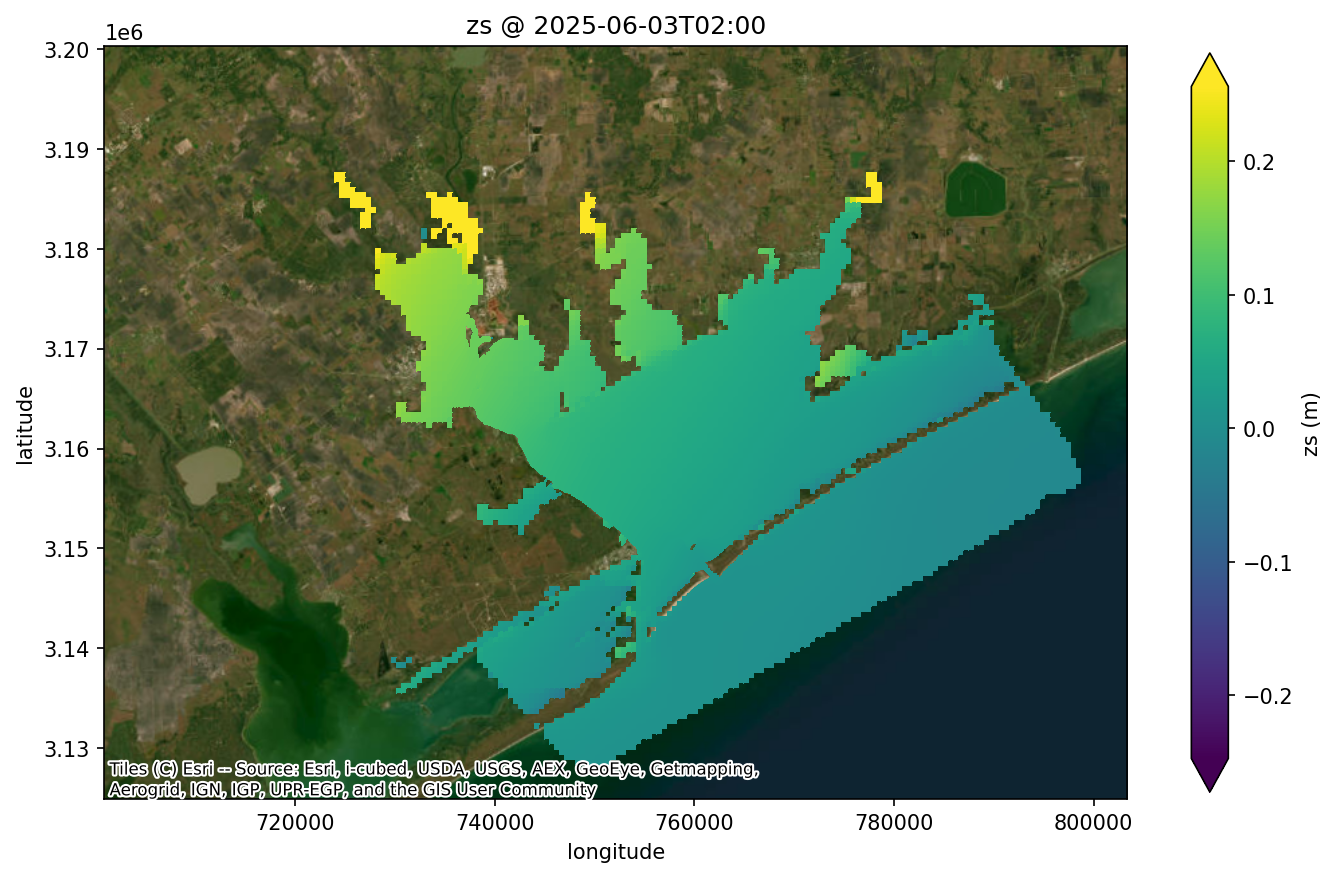

In [16]:
fig, ax = plt.subplots(figsize=(11, 8))
plot_water_level(
    ds,
    time=snapshot_indices[1],
    variable="zs",
    ax=ax,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    colorbar=True,
    basemap=True,
)
basemap_png = figs_dir / "water_level_with_basemap.png"
fig.savefig(basemap_png, dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(basemap_png), width=800))

## 12. Animate the evolution

`animate_water_level` reuses the frame builder from `plot_water_level`,
so the wet-cell mask is also applied to every frame.

In [17]:
from IPython.display import Video

anim_path = animate_water_level(
    ds,
    figs_dir / "water_level_animation.mp4",
    variable="zs",
    fps=10,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    title_prefix="Lavaca Bay",
    mask_dry=True,
    dry_threshold=DRY_THRESHOLD,
)
Video(str(anim_path), embed=True, width=800)

wrote                                                                           
docs/examples/lavaca-tx/run/sfincs_model/f
igs/water_level_animation.mp4 (101 frames, 10 fps)                              


## 13. Water-level time series at user-specified points

The plot stage accepts a CSV of observation points via
`SfincsModelConfig.obs_points_csv`; it interpolates the water-surface
elevation at each point by nearest-face lookup on the quadtree mesh
and writes `obs_water_level.parquet` next to the model output.

Here we drive the same machinery directly. We pick three points that
trace a head-to-shelf transect across the bay:

- `upper_bay_head`: inland tip of the bay, ~ (−96.57, +28.64).
- `mid_bay`: near the geographic center of the wet domain, ~ (−96.47, +28.53).
- `open_shelf`: south of the bay mouth, ~ (−96.40, +28.35).

In [18]:
import pandas as pd

from coastal_calibration.observations import (
    extract_water_level_series,
    load_obs_points,
    validate_points_in_domain,
)

obs_csv = run_dir / "user_obs_points.csv"
pd.DataFrame(
    {
        "id": ["upper_bay_head", "mid_bay", "open_shelf"],
        "lon": [-96.5743, -96.4669, -96.3992],
        "lat": [+28.6361, +28.5297, +28.3462],
    }
).to_csv(obs_csv, index=False)

points = load_obs_points(obs_csv)
validate_points_in_domain(points, ds)
series = extract_water_level_series(ds, points, variable="zs")
print(series.describe().loc[["min", "50%", "mean", "max"]].round(3))

      upper_bay_head  mid_bay  open_shelf
min           -0.265   -0.258      -0.329
50%            0.126    0.095       0.080
mean           0.086    0.061       0.043
max            0.314    0.247       0.268


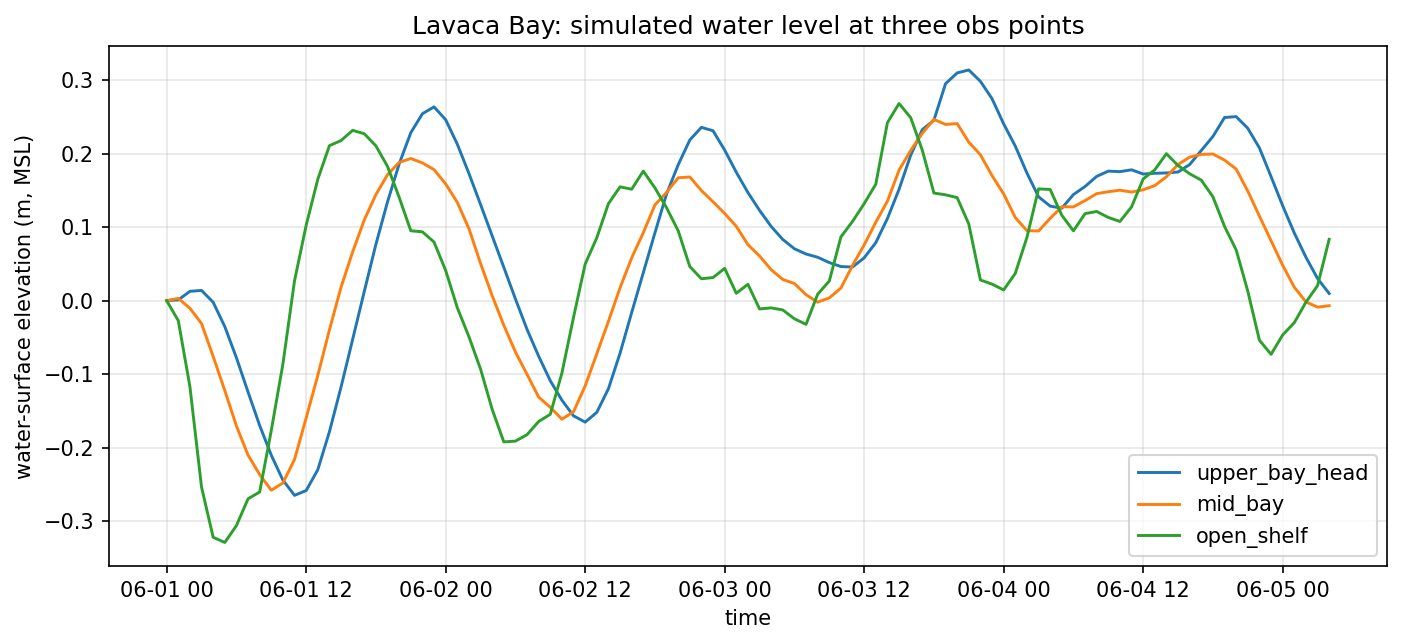

In [19]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for col in series.columns:
    ax.plot(series.index, series[col], label=col, linewidth=1.4)
ax.set_xlabel("time")
ax.set_ylabel("water-surface elevation (m, MSL)")
ax.set_title("Lavaca Bay: simulated water level at three obs points")
ax.legend(loc="best")
ax.grid(alpha=0.3)
ts_png = figs_dir / "obs_timeseries.png"
fig.savefig(ts_png, dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(ts_png), width=900))

## Summary

This notebook demonstrated the full Lavaca Bay SFINCS workflow via the
Python API:

1. `SfincsCreateConfig.from_dict({...})` + `SfincsCreator(config).run()`
   — built the model from an AOI.
2. `CoastalCalibConfig.from_dict({...})` + `CoastalCalibRunner(config).run()`
   — downloaded data, ran SFINCS, and compared results against NOAA
   observations.
3. Inspected the quadtree mesh (`SfincsGridInfo`, `plot_mesh`) and the
   downscaled flood depth map (`plot_floodmap`).
4. Drove the post-processing plotting API directly: water-surface and
   depth snapshots, anomaly view, satellite basemap overlay, animation,
   and time series at user-specified observation points.